# Midwest US: Daily Sentinel-2 Array

This notebook demonstrates how to use `lazycogs` to lazily load a daily array of Sentinel-2 Level 2A data over a large area of the Midwest US. The array spans summer 2025 (June–September) at 100 m resolution in EPSG:5070.

In [1]:
from pathlib import Path

import rustac
from pyproj import Transformer

import lazycogs

Define the area of interest with a CRS and a bounding box.

In [2]:
# define the AOI in/ a projection that is suitable for your analysis
dst_crs = "epsg:5070"
dst_bbox = (-700_000, 2_220_000, 600_000, 2_930_000)

# transform to epsg:4326 for STAC search
transformer = Transformer.from_crs(dst_crs, "epsg:4326", always_xy=True)
bbox_4326 = transformer.transform_bounds(*dst_bbox)

Query a STAC API and cache the result to a local stac-geoparquet file using `rustac`. This file will be used by the `lazycogs` backend to determine which COGs are required for which array operations.

This example generates an archive of Sentinel 2 Level 2A items for the summer months of 2025 for an area that covers a large part of Minnesota, USA.

In [3]:
PARQUET = "data/midwest_summer_2025.parquet"

if not Path(PARQUET).exists():
    Path(PARQUET).parent.mkdir(exist_ok=True)
    await rustac.search_to(
        PARQUET,
        href="https://earth-search.aws.element84.com/v1",
        collections=["sentinel-2-c1-l2a"],
        datetime="2025-06-01/2025-09-30",
        bbox=bbox_4326,
        limit=100,
    )

print(f"Using {PARQUET}")

Using data/midwest_summer_2025.parquet


Use the stac-geoparquet file to infer the object storage backend for these items (uses first item). Add `skip_signature=True` because these assets are in a public bucket.

In [4]:
store = lazycogs.store_for(PARQUET, skip_signature=True)

Open a 100% lazy `DataArray` representation of the assets referenced in the stac-geoparquet file for your specified CRS and bounding box and resolution. Provide the `store` we created above.

In [5]:
da = lazycogs.open(
    PARQUET,
    crs=dst_crs,
    bbox=dst_bbox,
    resolution=100,
    time_period="P1D",
    bands=["red", "green", "blue"],
    dtype="int16",
    store=store,
)

da

<xarray.DataArray (band: 3, time: 121, y: 7100, x: 13000)> Size: 67GB
[33504900000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 57kB 2.22e+06 2.22e+06 2.22e+06 ... 2.93e+06 2.93e+06
  * x        (x) float64 104kB -7e+05 -6.998e+05 -6.998e+05 ... 5.998e+05 6e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Get all of the values from June for a single point.

In [6]:
%%time
(
    da.sel(x=299965, y=2653947, method="nearest")
    .sel(time=slice("2025-06-01", "2025-06-30"))
    .compute()
)

CPU times: user 1.39 s, sys: 286 ms, total: 1.68 s
Wall time: 4.67 s


<xarray.DataArray (band: 3, time: 30)> Size: 180B
array([[    0,  2578,     0,  2688,     0, 10193,  2548,     0, 11786,
            0,     0,  8685,     0,  8705,     0,     0,  3066,     0,
        11911,     0,     0,  8338,     0,  2598,     0,  8146, 11202,
            0,  2503,     0],
       [    0,  2482,     0,  2521,     0, 10286,  2439,     0, 12660,
            0,     0,  8963,     0,  8460,     0,     0,  3109,     0,
        12683,     0,     0,  8437,     0,  2477,     0,  8041, 11309,
            0,  2480,     0],
       [    0,  2326,     0,  2307,     0, 10744,  2210,     0, 14304,
            0,     0,  9378,     0,  8434,     0,     0,  2949,     0,
        14094,     0,     0,  8874,     0,  2227,     0,  8012, 11754,
            0,  2258,     0]], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 240B 2025-06-01 2025-06-02 ... 2025-06-30
    y        float64 8B 2.654e+06
    x        float64 8B 3e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Select a spatial subset

In [7]:
subset = da.sel(
    x=slice(100_000, 400_000),
    y=slice(2_600_000, 2_800_000),
)
subset

<xarray.DataArray (band: 3, time: 121, y: 2000, x: 3000)> Size: 4GB
[2178000000 values with dtype=int16]
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
  * time     (time) datetime64[s] 968B 2025-06-01 2025-06-02 ... 2025-09-30
  * y        (y) float64 16kB 2.6e+06 2.6e+06 2.6e+06 ... 2.8e+06 2.8e+06
  * x        (x) float64 24kB 1e+05 1.002e+05 1.002e+05 ... 3.998e+05 4e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Extract the values for a single point

In [8]:
%%time
subset.isel(time=1, x=0, y=0).compute()

CPU times: user 306 ms, sys: 111 ms, total: 417 ms
Wall time: 1.96 s


<xarray.DataArray (band: 3)> Size: 6B
array([1775, 1938, 1705], dtype=int16)
Coordinates:
  * band     (band) <U5 60B 'red' 'green' 'blue'
    time     datetime64[s] 8B 2025-06-02
    y        float64 8B 2.6e+06
    x        float64 8B 1e+05
Attributes:
    _stac_backend:      MultiBandStacBackendArray(bands=['red', 'green', 'blu...
    _stac_time_coords:  2025-06-01 … 2025-09-30 (n=121)

Use the `stac_cog.explain()` accessor to learn about the underlying assets that will need to be accessed for a particular query.

In [9]:
plan = subset.isel(time=slice(1, 4)).lazycogs.explain(fetch_headers=True)
print(plan.summary())

=== ExplainPlan ===
Parquet:    data/midwest_summer_2025.parquet
CRS:        epsg:5070  |  Resolution: 100.0 units/px  |  Grid: 3000 x 2000 px
Bands (3):  red, green, blue
Time steps: 3 (2025-06-02 - 2025-06-04)
Chunks:     3000 x 2000 px -> 1x1 spatial tiles

Total chunk reads:     9 (3 band(s) x 3 time step(s) x 1 spatial tile(s))
Total COG reads:       57
Chunks with 0 COGs:       3 (33.3%)
Chunks with 1 COG:        0 (0.0%)
Chunks with 2+ COGs:      6 (66.7%)
Max COGs per chunk:    12
Overview levels:       ovr 2: 57
Avg read window:       1092 x 955 px
(Use .to_dataframe() for per-item overview and window details.)


Plot an RGB image of the subset area

CPU times: user 26.2 s, sys: 1.59 s, total: 27.8 s
Wall time: 13.5 s


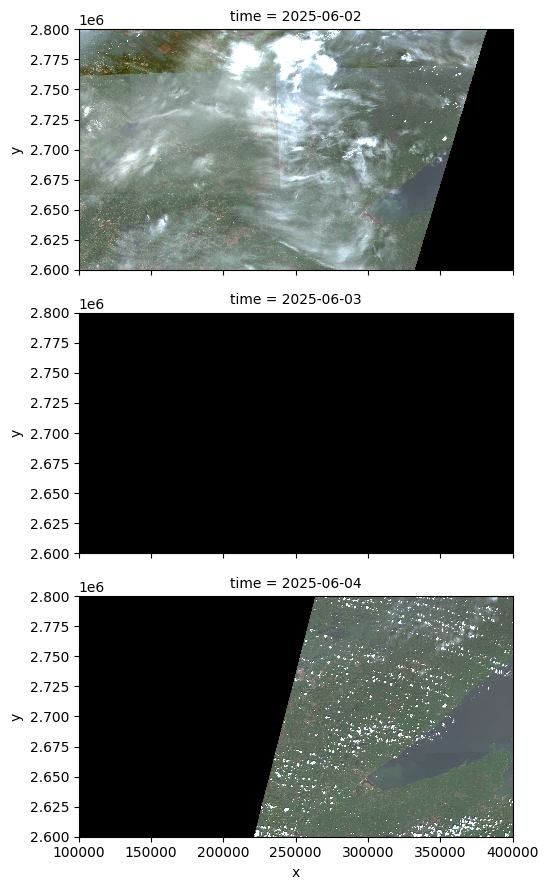

In [10]:
%%time
(
    subset.isel(time=slice(1, 4)).plot.imshow(
        rgb="band",
        row="time",
        vmin=0,
        vmax=4000,
        aspect=subset.shape[3] / subset.shape[2],
    )
)